# Effectiveness of thrombolysis and thrombectomy in early (6hr) arrivals of non-mild stroke - survival

## Selection criteria

* Arrival within 6 hours of known stroke onset time
* Thrombectomy, if given, given within 12 hours
* Thrombolysis, if given, given within 6 hours
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity > 5 (or labelled as LVO)

## Outcome of interest

* Survive to discharge (mRS 0-5).

## Key features of interest

* Onset to thrombolysis time
* Onset to thrombectomy time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Methodology steps

* Select patients by above criteria
* Select features by above criteria
* Split data in 5 sets, where 80% of data is used to train a model, and tets results are generated for the remaining 20% (each patient is in a single test set)
* Train 5 models
* For each model get outcome results for the tets set
* For each model, for patients treated with thrombolysis or thrombectomy, get counterfactual outcomes if they had no treatment
* Calculate the difference between actual outcome and (counterfactual) no-treatment outcomes for treated patients
* Analyse resuls for patients who 1) received thrombectomy only, 2) thrombolysis only, 3) thrombolysis or thrombectomy *

*Note - though the analysis is by different groups, the models are fitted to all groups (no treatment, thrombolysis alone, thrombectomy alone, thrombolysis + thrombectomy).

## Load modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier 

## Define mRS outcome target

In [2]:
mrs_target = 5 # Model will set y as being less than or equal to this value

## Define adjustment fields

In [3]:
non_categorical_features = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time']

categorical_features = [
    'stroke_team',
    'ethnicity',
]

X_fields = non_categorical_features + categorical_features

## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

# Ensure categorical columns are pandas categorical dtype for XGBoost
for col in categorical_features:
    data[col] = data[col].replace("", "Empty")
    data[col] = data[col].astype("category")

# Ensure non-categorical columns are numeric
for col in non_categorical_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")


Initial data shape: (452863, 70)
Final data shape: (76337, 70)
Number of patients with thrombectomy: 4645
Number of patients with both thrombolysis and thrombectomy: 2898
Number of patients with only thrombectomy: 1747
Number of patients with thrombolysis: 34182
Number of patients with only thrombolysis: 31284


## Create 5 k-fold splits

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data[X_fields]
y = (data['discharge_disability'] <= mrs_target).astype(int)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []

for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]
    
    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

## Train and test models

In [6]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]
    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 3.6
    )
    # Train model
    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.7858, Balanced Accuracy = 0.6391
Split 2: AUC = 0.7864, Balanced Accuracy = 0.6445
Split 3: AUC = 0.7891, Balanced Accuracy = 0.6411
Split 4: AUC = 0.7896, Balanced Accuracy = 0.6363
Split 5: AUC = 0.7873, Balanced Accuracy = 0.6428


In [7]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred_proba = test_y_pred_probas[split]
    y_pred = test_y_preds[split]
    
    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()
    
    print(f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, Predicted positive rate = {predicted_pos_rate:.4f}")

Split 1: Actual positive rate = 0.8367, Predicted positive rate = 0.8814
Split 2: Actual positive rate = 0.8367, Predicted positive rate = 0.8813
Split 3: Actual positive rate = 0.8368, Predicted positive rate = 0.8873
Split 4: Actual positive rate = 0.8368, Predicted positive rate = 0.8866
Split 5: Actual positive rate = 0.8368, Predicted positive rate = 0.8807


## Predict counterfactual outcomes

To mimic no thrombolysis or thrombectomy, set times to 99999.

In [8]:
counter_factuals = []

for split in range(5):
    # Get model and data
    model = models[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]

    # Get index of patients who received thrombectomy or thrombolysis
    treated_indices = test_X[
        (test_X['onset_to_thrombectomy_time'] < 99999) |
        (test_X['onset_to_thrombolysis_time'] < 99999)].index

    # Get X and y for these patients
    thrombectomy_X = test_X.loc[treated_indices]
    thrombectomy_y = test_y.loc[treated_indices]

    # Get predicted probabilities for these patients
    y_probs = model.predict_proba(thrombectomy_X)[:, 1]
    
    # No thrombolysis scenario: Set onset_to_thrombolysis_time to 99999 for these patients
    no_thrombolysis_X = thrombectomy_X.copy(deep=True)
    no_thrombolysis_X['onset_to_thrombolysis_time'] = 99999
    y_probs_no_thrombolysis = model.predict_proba(no_thrombolysis_X)[:, 1]

    # No thrombectomy scenario: Set onset_to_thrombectomy_time to 99999 for these patients
    no_thrombectomy_X = thrombectomy_X.copy(deep=True)
    no_thrombectomy_X['onset_to_thrombectomy_time'] = 99999
    y_probs_no_thrombectomy = model.predict_proba(no_thrombectomy_X)[:, 1]

    # No thrombolysis and no thrombectomy scenario: Set both times to 99999
    no_both_X = thrombectomy_X.copy(deep=True)
    no_both_X['onset_to_thrombolysis_time'] = 99999
    no_both_X['onset_to_thrombectomy_time'] = 99999
    y_probs_no_both = model.predict_proba(no_both_X)[:, 1]

    # Combine X, y, and store the counterfactuals for this split
    counter_factuals_split = thrombectomy_X.copy(deep=True)
    counter_factuals_split.insert(0, 'patient_index', treated_indices)
    counter_factuals_split['actual_y'] = thrombectomy_y
    counter_factuals_split['y_prob_treated'] = y_probs
    counter_factuals_split['y_prob_no_thrombolysis'] = y_probs_no_thrombolysis
    counter_factuals_split['y_prob_no_thrombectomy'] = y_probs_no_thrombectomy
    counter_factuals_split['y_prob_no_treatment'] = y_probs_no_both
    counter_factuals_split['treatment_diff_prob'] = y_probs - y_probs_no_both
    counter_factuals.append(counter_factuals_split)

# Combine all counterfactuals into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

# Add a column of treatment group, based on times to treatment
def treatment_group(row):
    if row["onset_to_thrombolysis_time"] != 99999 and row["onset_to_thrombectomy_time"] != 99999:
        return "both"
    elif row["onset_to_thrombolysis_time"] != 99999:
        return "thrombolysis_only"
    elif row["onset_to_thrombectomy_time"] != 99999:
        return "thrombectomy_only"
    else:
        return "neither"
    
counter_factuals_df["treatment_group"] = counter_factuals_df.apply(treatment_group, axis=1)

In [9]:
# Define columns for probabilities and compute log-odds
prob_cols = [
    'y_prob_treated',
    'y_prob_no_thrombolysis',
    'y_prob_no_thrombectomy',
    'y_prob_no_treatment',
]

# Convert predicted probabilities to clipped log-odds columns
for col in prob_cols:
    clipped = counter_factuals_df[col].clip(1e-9, 1 - 1e-9)
    log_odds_col = col.replace('y_prob_', 'log_odds_')
    counter_factuals_df[log_odds_col] = np.log(clipped / (1 - clipped))

diff_pairs = {
    'log_odds_diff_treated_no_thrombolysis': 'log_odds_no_thrombolysis',
    'log_odds_diff_treated_no_thrombectomy': 'log_odds_no_thrombectomy',
    'log_odds_diff_treated_no_treatment': 'log_odds_no_treatment',
}

for diff_col, ref_col in diff_pairs.items():
    counter_factuals_df[diff_col] = (
        counter_factuals_df['log_odds_treated'] - counter_factuals_df[ref_col]
    )

## Descriptive statistics of all patients in model

In [10]:
counter_factuals_df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_index,35929.0,231349.214729,132469.136917,10.000000,116238.000000,235330.000000,346616.000000,452855.000000
prior_disability,35929.0,0.911492,1.249433,0.000000,0.000000,0.000000,2.000000,5.000000
stroke_severity,35906.0,13.258397,6.306211,0.000000,8.000000,12.000000,18.000000,42.000000
age,35929.0,73.588675,13.360435,37.500000,67.500000,77.500000,82.500000,92.500000
congestive_heart_failure,35929.0,0.053606,0.225241,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,35929.0,0.541652,0.498269,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,35929.0,0.206073,0.404489,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,35929.0,0.053968,0.225957,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,35929.0,0.229091,0.420254,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,35929.0,5021.606446,21472.145460,14.000000,126.000000,164.000000,215.000000,99999.000000


Descriptive statistics for treatment group: thrombectomy_only

In [11]:
group = 'thrombectomy_only'
group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == group]
print(f"\nDescriptive stats for treatment group: {group}")
group_df.describe().T


Descriptive stats for treatment group: thrombectomy_only


,count,mean,std,min,25%,50%,75%,max
patient_index,1747.0,305283.559817,92768.625471,105650.000000,232585.500000,309794.000000,384892.500000,452563.000000
prior_disability,1747.0,0.610189,0.825405,0.000000,0.000000,0.000000,1.000000,5.000000
stroke_severity,1746.0,16.100229,6.122974,0.000000,11.000000,16.000000,21.000000,40.000000
age,1747.0,73.264167,12.972012,37.500000,67.500000,77.500000,82.500000,92.500000
congestive_heart_failure,1747.0,0.085289,0.279391,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,1747.0,0.546651,0.497961,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,1747.0,0.187178,0.390166,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,1747.0,0.459645,0.498512,0.000000,0.000000,0.000000,1.000000,1.000000
any_afib_diagnosis,1747.0,0.516886,0.499858,0.000000,0.000000,1.000000,1.000000,1.000000
onset_to_thrombolysis_time,1747.0,99999.000000,0.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000


Descriptive statistics for treatment group: thrombolysis only

In [12]:
group = 'thrombolysis_only'
group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == group]
print(f"\nDescriptive stats for treatment group: {group}")
group_df.describe().T


Descriptive stats for treatment group: thrombolysis_only


,count,mean,std,min,25%,50%,75%,max
patient_index,31284.0,221170.762978,134074.792270,10.000000,101064.500000,219959.500000,338458.000000,452855.000000
prior_disability,31284.0,0.978136,1.293230,0.000000,0.000000,0.000000,2.000000,5.000000
stroke_severity,31262.0,12.833344,6.228982,0.000000,8.000000,11.000000,17.000000,42.000000
age,31284.0,73.865554,13.372882,37.500000,67.500000,77.500000,82.500000,92.500000
congestive_heart_failure,31284.0,0.052902,0.223842,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,31284.0,0.545295,0.497952,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,31284.0,0.211546,0.408411,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,31284.0,0.033500,0.179940,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,31284.0,0.211642,0.408479,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,31284.0,168.820899,56.434681,14.000000,125.000000,161.000000,208.000000,359.000000


Descriptive statistics for treatment group: thrombolysis + thrombectomy

In [13]:
group = 'both'
group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == group]
print(f"\nDescriptive stats for treatment group: {group}")
group_df.describe().T


Descriptive stats for treatment group: both


,count,mean,std,min,25%,50%,75%,max
patient_index,2898.0,296656.110421,98216.166911,106695.000000,219260.500000,304821.000000,383008.250000,452623.000000
prior_disability,2898.0,0.373706,0.705586,0.000000,0.000000,0.000000,1.000000,5.000000
stroke_severity,2898.0,16.131470,6.044791,0.000000,11.000000,16.000000,20.000000,37.000000
age,2898.0,70.795376,13.133882,37.500000,62.500000,72.500000,82.500000,92.500000
congestive_heart_failure,2898.0,0.042098,0.200847,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,2898.0,0.499310,0.500086,0.000000,0.000000,0.000000,1.000000,1.000000
diabetes,2898.0,0.158385,0.365165,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,2898.0,0.030366,0.171621,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,2898.0,0.243961,0.429544,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,2898.0,152.398896,55.386790,22.000000,112.000000,142.000000,185.000000,358.000000


Get mean, standard deviation, and n for each treatment group

In [14]:
# Get mean, standard deviation, and n for each feature in each treatment group, and store in a DataFrame
treatments_groups = ['both', 'thrombolysis_only', 'thrombectomy_only']
treatment_effects = ['y_prob_treated','y_prob_no_treatment', 'treatment_diff_prob', 'log_odds_no_treatment']
# Get mean, standard deviation, and n for each treatment effect in treatment group, and store in a DataFrame
summary_stats = []
for treatment in treatments_groups:
    for effect in treatment_effects:
        group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == treatment]
        mean = group_df[effect].mean()
        std = group_df[effect].std()
        n = group_df[effect].count()
        summary_stats.append({
            'treatment_group': treatment,
            'treatment_effect': effect,
            'mean': mean,
            'std': std,
            'n': n
        })
summary_stats_df = pd.DataFrame(summary_stats).round(3)
summary_stats_df

,treatment_group,treatment_effect,mean,std,n
0,both,y_prob_treated,0.870,0.175,2898
1,both,y_prob_no_treatment,0.761,0.211,2898
2,both,treatment_diff_prob,0.109,0.145,2898
3,both,log_odds_no_treatment,1.716,1.680,2898
4,thrombolysis_only,y_prob_treated,0.853,0.184,31284
5,thrombolysis_only,y_prob_no_treatment,0.810,0.203,31284
6,thrombolysis_only,treatment_diff_prob,0.043,0.093,31284
7,thrombolysis_only,log_odds_no_treatment,2.158,1.743,31284
8,thrombectomy_only,y_prob_treated,0.790,0.215,1747
9,thrombectomy_only,y_prob_no_treatment,0.718,0.230,1747


Add 60 minute bins of thrombolysis and thrombectomy time.

In [15]:
# 60-minute bins up to 720, plus sentinel 99999
bin_edges = list(range(0, 361, 60)) + [99999]

# Labels like 0-120, 120-240, ..., 600-720, No treatment
bin_labels = [
    f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges) - 2)] + ["No thrombolysis"]
counter_factuals_df['thrombolysis_bin'] = pd.cut(
    counter_factuals_df['onset_to_thrombolysis_time'],
    bins=bin_edges,
    labels=bin_labels,
    right=True,
    include_lowest=True
)

bin_edges = list(range(0, 721, 60)) + [99999]
bin_labels = [
    f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges) - 2)] + ["No thrombectomy"]
counter_factuals_df['thrombectomy_bin'] = pd.cut(
    counter_factuals_df['onset_to_thrombectomy_time'],
    bins=bin_edges,
    labels=bin_labels,
    right=True,
    include_lowest=True
)

## Plot heatmap of benefit vs thrombolysis and thrombectomy time

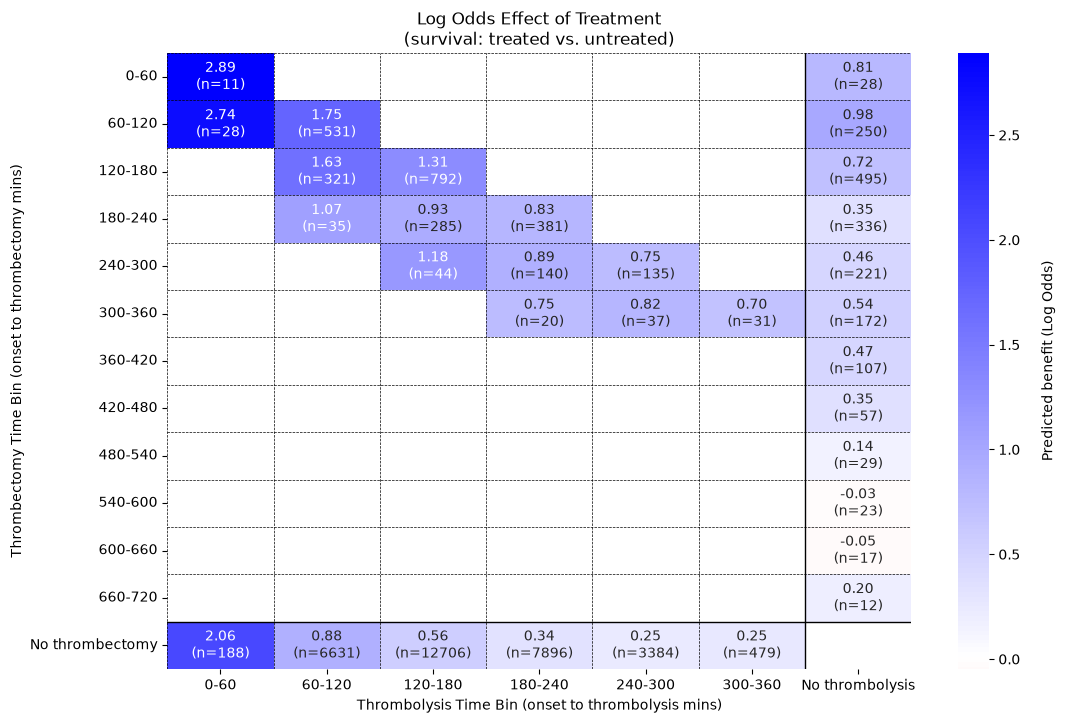

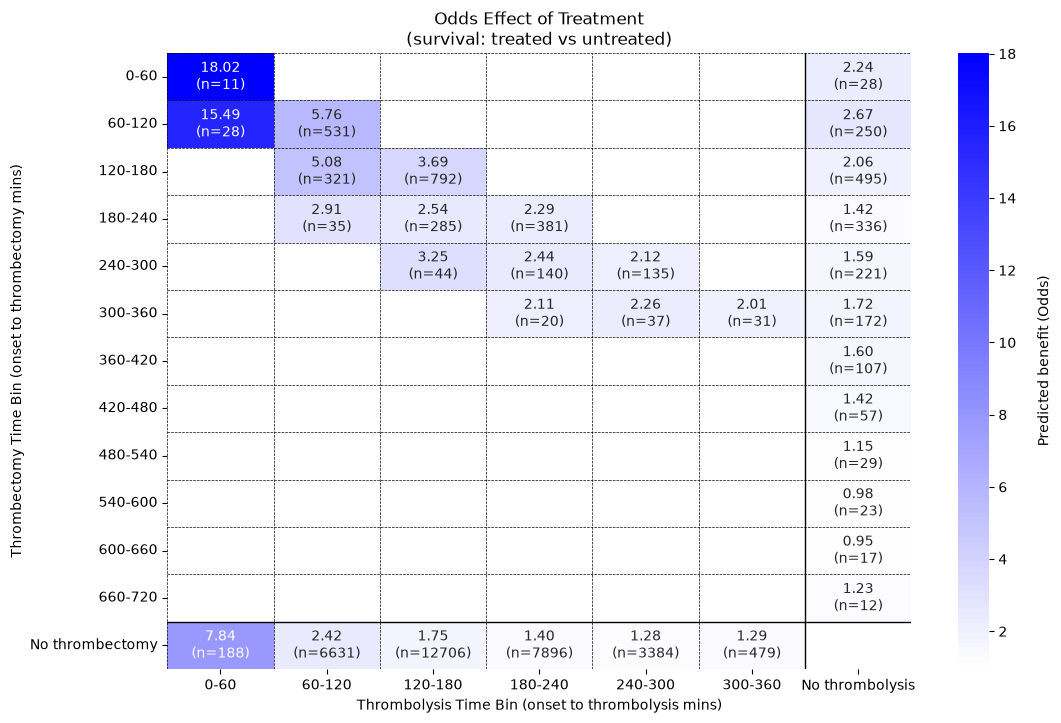

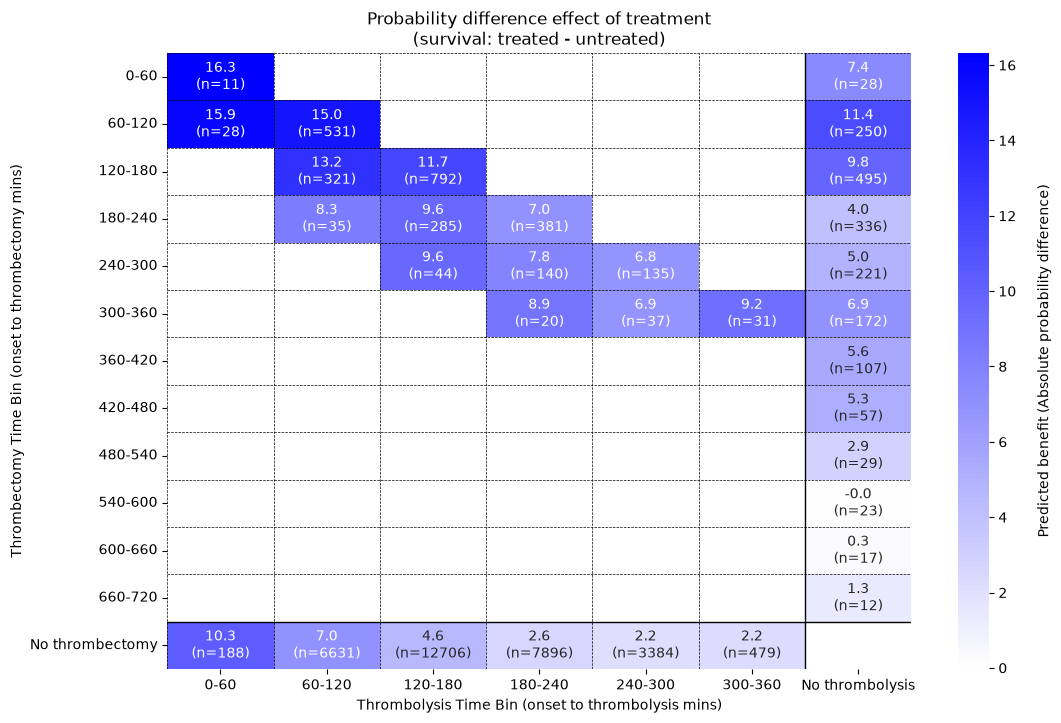

In [16]:
# Preoduce heatmap of difference to no treatment for thrombectomy and thrombolysis, with bins on x and y axes
heatmap_data = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='log_odds_diff_treated_no_treatment',
    aggfunc='mean'
)

# Remove any cells where the count is less than 5 to avoid unreliable estimates
heatmap_counts = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='patient_index',
    aggfunc='count'
)

# Filter heatmap_data to only include cells with counts >= 10
heatmap_data = heatmap_data.where(heatmap_counts >= 10)

# Create annotation labels without changing heatmap_data numeric dtype
heatmap_annot = heatmap_data.apply(
    lambda col: col.map(lambda v: f"{float(v):.2f}" if pd.notna(v) else "")
)

# Add (n=count) to the annotation labels
heatmap_annot = heatmap_annot + heatmap_counts.apply(
    lambda col: col.map(lambda v: f"\n(n={int(v)})" if pd.notna(v) and v >=10 else ""))


# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='bwr_r', center=0, annot=heatmap_annot, fmt='')
plt.title(f'Log Odds Effect of Treatment\n(survival: treated vs. untreated)')

# Add lines between all bins
for i in range(len(bin_labels)):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.5)
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.5)

# Count the number of bins for thrombolysis and thrombectomy,
# and draw a solid line at the last bin for each axis.
thrombolysis_bin_count = len(counter_factuals_df['thrombolysis_bin'].cat.categories)
thrombectomy_bin_count = len(counter_factuals_df['thrombectomy_bin'].cat.categories)
plt.axvline(x=thrombolysis_bin_count - 1, color='black', linestyle='-', linewidth=1)
plt.axhline(y=thrombectomy_bin_count - 1, color='black', linestyle='-', linewidth=1)

# Add a label to the colorbar
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Predicted benefit (Log Odds)', rotation=90, labelpad=15)

plt.xlabel('Thrombolysis Time Bin (onset to thrombolysis mins)')
plt.ylabel('Thrombectomy Time Bin (onset to thrombectomy mins)')
plt.savefig(f'./output/thrombolysis_thrombectomy_heatmap_mrs_{mrs_target}.png',
            dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# Repeat the heatmap but with lod odds convert to odds (exp log odds)
################################################################################

heatmap_data_odds = np.exp(heatmap_data)
heatmap_annot_odds = heatmap_data_odds.apply(
    lambda col: col.map(lambda v: f"{float(v):.2f}" if pd.notna(v) else "")
)
# Add (n=count) to the annotation labels
heatmap_annot_odds = heatmap_annot_odds + heatmap_counts.apply(
    lambda col: col.map(lambda v: f"\n(n={int(v)})" if pd.notna(v) and v >=10 else "")
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_odds, cmap='bwr_r', center=1, annot=heatmap_annot_odds, fmt='')
plt.title(f'Odds Effect of Treatment\n(survival: treated vs untreated)')

# Add lines between all bins
for i in range(len(bin_labels)):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.5)
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.5)

# Count the number of bins for thrombolysis and thrombectomy,
# and draw a solid line at the last bin for each axis.
plt.axvline(x=thrombolysis_bin_count - 1, color='black', linestyle='-', linewidth=1)
plt.axhline(y=thrombectomy_bin_count - 1, color='black', linestyle='-', linewidth=1)

# Add a label to the colorbar
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Predicted benefit (Odds)', rotation=90, labelpad=15)

plt.xlabel('Thrombolysis Time Bin (onset to thrombolysis mins)')
plt.ylabel('Thrombectomy Time Bin (onset to thrombectomy mins)')
plt.savefig(f'./output/thrombolysis_thrombectomy_heatmap_odds_mrs_{mrs_target}.png',
            dpi=300, bbox_inches='tight')
plt.show()


################################################################################
# Repeat for treatment_difference (y_probs - y_probs_no_both) instead of log 
# odds difference 
################################################################################

heatmap_data = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='treatment_diff_prob',
    aggfunc='mean'
)

# Remove any cells where the count is less than 5 to avoid unreliable estimates
heatmap_counts = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='patient_index',
    aggfunc='count'
)

# Filter heatmap_data to only include cells with counts >= 10
heatmap_data_diff = heatmap_data.where(heatmap_counts >= 10)

# Convert to percentage
heatmap_data_diff = heatmap_data_diff * 100

# Create annotation labels without changing heatmap_data numeric dtype
heatmap_annot = heatmap_data_diff.apply(
    lambda col: col.map(lambda v: f"{float(v):.1f}" if pd.notna(v) else "")
)
# Add (n=count) to the annotation labels
heatmap_annot = heatmap_annot + heatmap_counts.apply(
    lambda col: col.map(lambda v: f"\n(n={int(v)})" if pd.notna(v) and v >=10 else ""))


# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_diff, cmap='bwr_r', center=0, annot=heatmap_annot, fmt='')
plt.title(f'Probability difference effect of treatment\n(survival: treated - untreated)')
# Add lines between all bins
for i in range(len(bin_labels)):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.5)
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.5)

# Count the number of bins for thrombolysis and thrombectomy,
# and draw a solid line at the last bin for each axis.
plt.axvline(x=thrombolysis_bin_count - 1, color='black', linestyle='-', linewidth=1)
plt.axhline(y=thrombectomy_bin_count - 1, color='black', linestyle='-', linewidth=1)

# Add a label to the colorbar
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Predicted benefit (Absolute probability difference)', rotation=90, labelpad=15)

plt.xlabel('Thrombolysis Time Bin (onset to thrombolysis mins)')
plt.ylabel('Thrombectomy Time Bin (onset to thrombectomy mins)')
plt.savefig(f'./output/thrombolysis_thrombectomy_heatmap_diff_prob_mrs_{mrs_target}.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Regression on time to thrombolysis and time to thrombectomy, when both given

In [17]:
# Get data for patients who thrombectomy and thrombolysis
both_treatments = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombectomy_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombolysis_time"] < 99999)
].copy()

# Fit multiple regression model for predicted benefit vs thrombolysis time
reg_X = both_treatments[["onset_to_thrombolysis_time", "onset_to_thrombectomy_time"]]
reg_y = both_treatments["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.101
Model:                                            OLS   Adj. R-squared:                  0.100
Method:                                 Least Squares   F-statistic:                     162.6
Date:                                Tue, 14 Jul 2026   Prob (F-statistic):           1.24e-67
Time:                                        12:12:54   Log-Likelihood:                -4510.6
No. Observations:                                2898   AIC:                             9027.
Df Residuals:                                    2895   BIC:                             9045.
Df Model:                                           2                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

Plot contour map

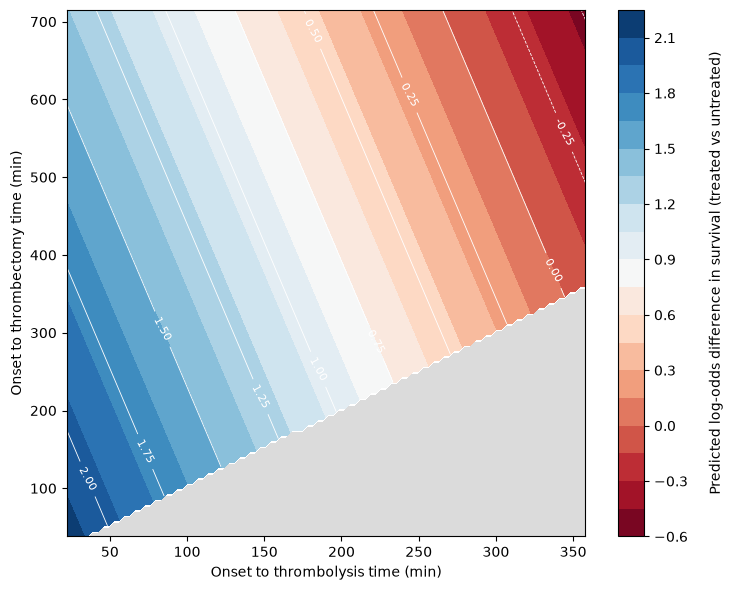

In [18]:
x1_grid = np.linspace(reg_X["onset_to_thrombolysis_time"].min(),
                       reg_X["onset_to_thrombolysis_time"].max(), 100)
x2_grid = np.linspace(reg_X["onset_to_thrombectomy_time"].min(),
                       reg_X["onset_to_thrombectomy_time"].max(), 100)

xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

const = model.params["const"]
c1 = model.params["onset_to_thrombolysis_time"]
c2 = model.params["onset_to_thrombectomy_time"]

zz = const + c1 * xx1 + c2 * xx2

# Mask points where thrombolysis time exceeds thrombectomy time
invalid_mask = xx1 > xx2
zz_masked = np.ma.masked_where(invalid_mask, zz)


fig, ax = plt.subplots(figsize=(7.5, 6))
cs_fill = ax.contourf(xx1, xx2, zz_masked, levels=20, cmap="RdBu")
cs_lines = ax.contour(xx1, xx2, zz_masked, levels=10, colors="white", linewidths=0.6)
ax.clabel(cs_lines, inline=True, fontsize=8, fmt="%.2f")

# Optionally shade the excluded region for clarity
ax.contourf(xx1, xx2, invalid_mask, levels=[0.5, 1.5], colors="lightgrey", alpha=0.8)

cbar = fig.colorbar(cs_fill, ax=ax)
cbar.set_label(
    f"Predicted log-odds difference in survival (treated vs untreated)",
    labelpad=15)

#ax.set_title("Predicted outcome across both time predictors")
ax.set_xlabel("Onset to thrombolysis time (min)")
ax.set_ylabel("Onset to thrombectomy time (min)")
fig.tight_layout()
fig.savefig(f"./output/contour_plot_mRS_{mrs_target}.png", dpi=300)
plt.show()

Marginal effect plots

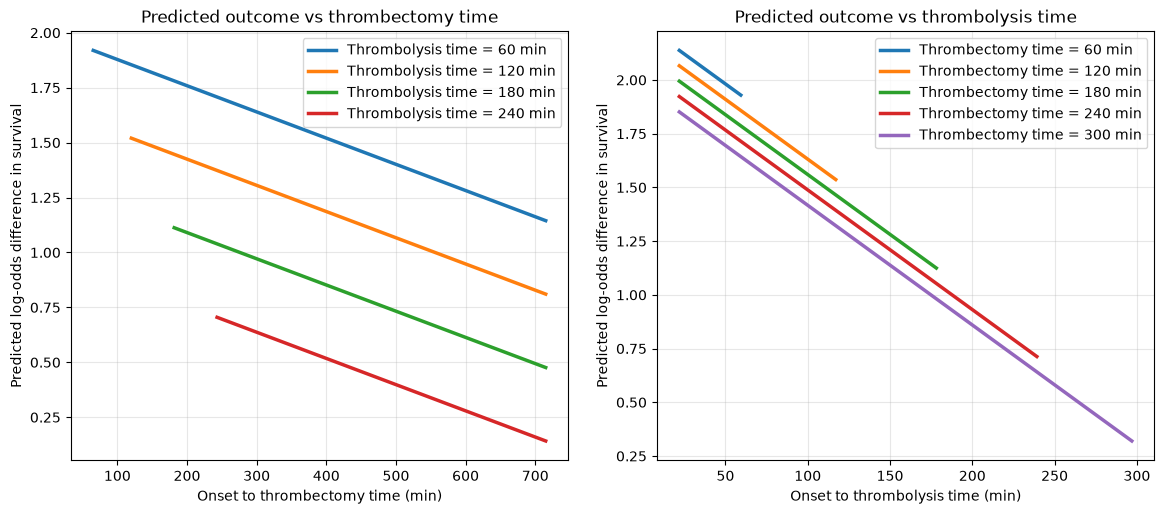

In [19]:
const = model.params["const"]
c1 = model.params["onset_to_thrombolysis_time"]
c2 = model.params["onset_to_thrombectomy_time"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Left panel: thrombectomy time on x-axis, lines fixed at thrombolysis times
thrombolysis_vals = [60, 120, 180, 240]
colors_left = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

x2_range = np.linspace(reg_X["onset_to_thrombectomy_time"].min(),
                        reg_X["onset_to_thrombectomy_time"].max(), 100)

ax = axes[0]
for x1_val, color in zip(thrombolysis_vals, colors_left):
    valid_mask = x2_range >= x1_val
    x2_valid = x2_range[valid_mask]
    y_pred = const + c1 * x1_val + c2 * x2_valid
    ax.plot(x2_valid, y_pred, color=color, linewidth=2.5,
            label=f"Thrombolysis time = {x1_val} min")

ax.set_title("Predicted outcome vs thrombectomy time")
ax.set_xlabel("Onset to thrombectomy time (min)")
ax.set_ylabel(f"Predicted log-odds difference in survival")
ax.legend()
ax.grid(alpha=0.3)

# Right panel: thrombolysis time on x-axis, lines fixed at thrombectomy times
thrombectomy_vals = [60, 120, 180, 240, 300]
colors_right = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

x1_range = np.linspace(reg_X["onset_to_thrombolysis_time"].min(),
                        reg_X["onset_to_thrombolysis_time"].max(), 100)
    
ax = axes[1]
for x2_val, color in zip(thrombectomy_vals, colors_right):
    valid_mask = x1_range <= x2_val
    x1_valid = x1_range[valid_mask]
    y_pred = const + c1 * x1_valid + c2 * x2_val
    ax.plot(x1_valid, y_pred, color=color, linewidth=2.5,
            label=f"Thrombectomy time = {x2_val} min")

ax.set_title("Predicted outcome vs thrombolysis time")
ax.set_xlabel("Onset to thrombolysis time (min)")
ax.set_ylabel(f"Predicted log-odds difference in survival")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout(pad=2.0)
fig.savefig(f"./output/marginal_effect_plot_mRS_{mrs_target}.png", dpi=300)
plt.show()


## Analysis of thrombectomy alone

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.052
Model:                                            OLS   Adj. R-squared:                  0.052
Method:                                 Least Squares   F-statistic:                     96.28
Date:                                Tue, 14 Jul 2026   Prob (F-statistic):           3.68e-22
Time:                                        12:12:54   Log-Likelihood:                -2163.7
No. Observations:                                1747   AIC:                             4331.
Df Residuals:                                    1745   BIC:                             4342.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

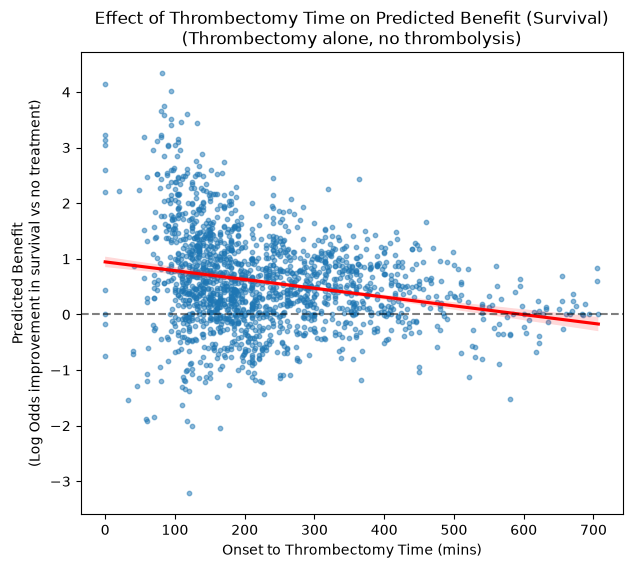

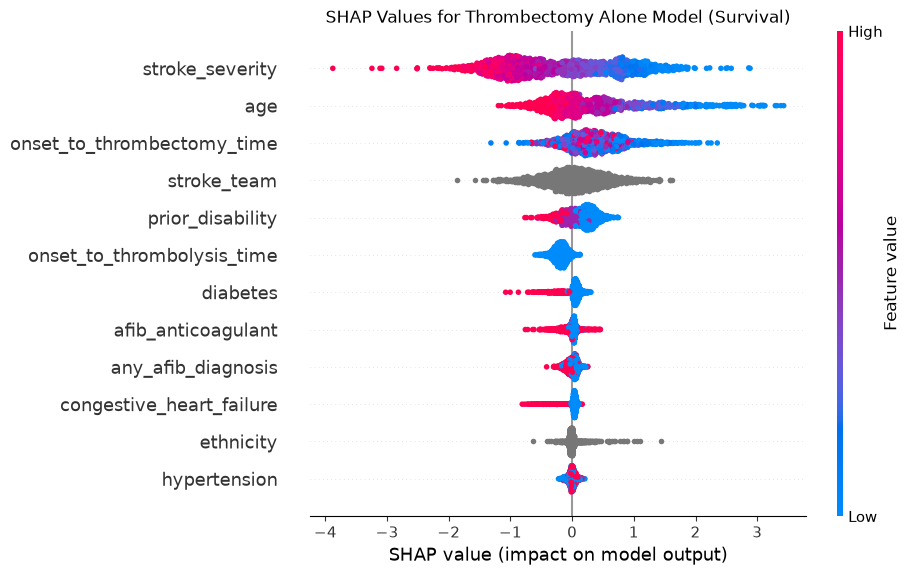

In [20]:
# Get data for patients who received only thrombectomy
only_thrombectomy = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombectomy_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombolysis_time"] == 99999)
].copy()

# Fit regression model for predicted benefit vs thrombectomy time
reg_X = only_thrombectomy[["onset_to_thrombectomy_time"]]
reg_y = only_thrombectomy["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombectomy_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombectomy_time", "onset_to_thrombectomy_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombectomy_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombectomy_time",
    y="log_odds_diff_treated_no_treatment",
    data=only_thrombectomy,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(
    f"Effect of Thrombectomy Time on Predicted Benefit (Survival)\n"
    "(Thrombectomy alone, no thrombolysis)"
)
plt.xlabel('Onset to Thrombectomy Time (mins)')
plt.ylabel(f'Predicted Benefit\n(Log Odds improvement in survival vs no treatment)')
plt.savefig(
    f'./output/thrombectomy_alone_time_effect_mrs_{mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()

# Use models[0] to get SHAP values patients receiving only thrombectomy
only_thrombectomy_X = only_thrombectomy[X_fields]
explainer = shap.Explainer(models[0])
shap_values = explainer(only_thrombectomy_X)
# Plot beeswarm plot for SHAP values
shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.title(f"SHAP Values for Thrombectomy Alone Model (Survival)")
plt.savefig(f'./output/shap_beeswarm_thrombectomy_alone_mrs_{mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis of thrombolysis alone

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.097
Model:                                            OLS   Adj. R-squared:                  0.097
Method:                                 Least Squares   F-statistic:                     3346.
Date:                                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                                        12:12:55   Log-Likelihood:                -34741.
No. Observations:                               31284   AIC:                         6.949e+04
Df Residuals:                                   31282   BIC:                         6.950e+04
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

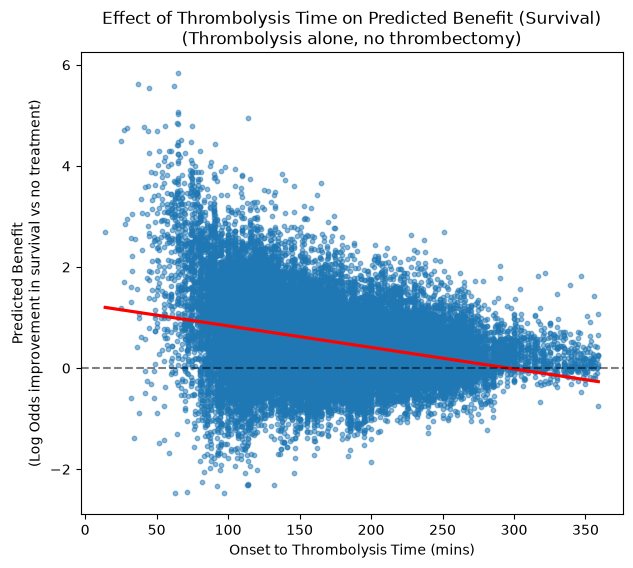

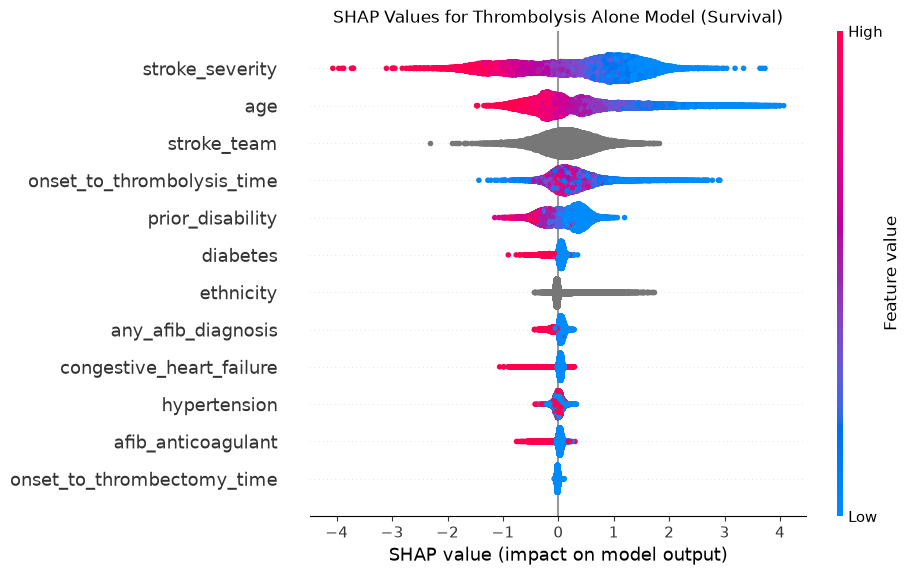

In [21]:
# Get data for patients who received only thrombolysis
only_thrombolysis = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombolysis_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombectomy_time"] == 99999)
].copy()

# Fit regression model for predicted benefit vs thrombolysis time
reg_X = only_thrombolysis[["onset_to_thrombolysis_time"]]
reg_y = only_thrombolysis["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombolysis_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombolysis_time", "onset_to_thrombolysis_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombolysis_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombolysis_time",
    y="log_odds_diff_treated_no_treatment",
    data=only_thrombolysis,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)

# Add a line at y=0
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.title(
    f"Effect of Thrombolysis Time on Predicted Benefit (Survival)\n"
    "(Thrombolysis alone, no thrombectomy)"
)
plt.xlabel("Onset to Thrombolysis Time (mins)")
plt.ylabel(
    f"Predicted Benefit\n(Log Odds improvement in survival vs no treatment)"
)
plt.savefig(
    f"./output/thrombolysis_alone_time_effect_mrs_{mrs_target}.png", dpi=300, bbox_inches="tight")

plt.show()

# Use models[0] to get SHAP values for patients receiving only thrombolysis
only_thrombolysis_X = only_thrombolysis[X_fields]
explainer = shap.Explainer(models[0])
shap_values = explainer(only_thrombolysis_X)

# Plot beeswarm plot for SHAP values
shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.title(f"SHAP Values for Thrombolysis Alone Model (Survival)")
plt.savefig(
    f"./output/shap_beeswarm_thrombolysis_alone_mrs_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Analysis of thrombectomy and thrombolysis (analyse time to thrombectomy)

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.067
Model:                                            OLS   Adj. R-squared:                  0.067
Method:                                 Least Squares   F-statistic:                     209.2
Date:                                Tue, 14 Jul 2026   Prob (F-statistic):           8.00e-46
Time:                                        12:12:59   Log-Likelihood:                -4563.7
No. Observations:                                2898   AIC:                             9131.
Df Residuals:                                    2896   BIC:                             9143.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

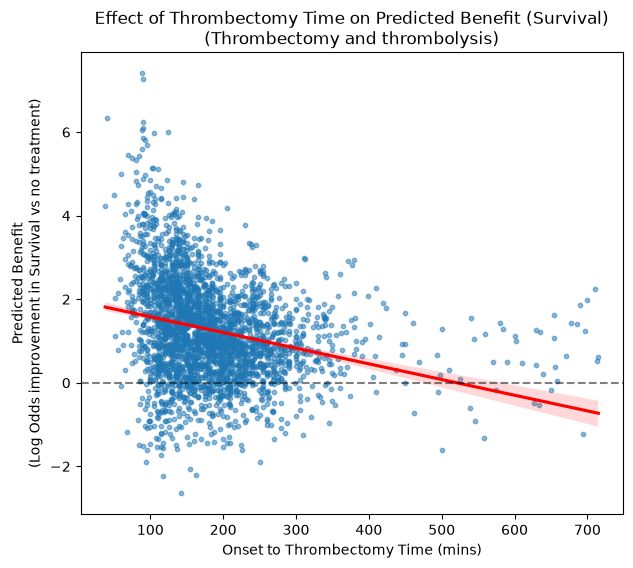

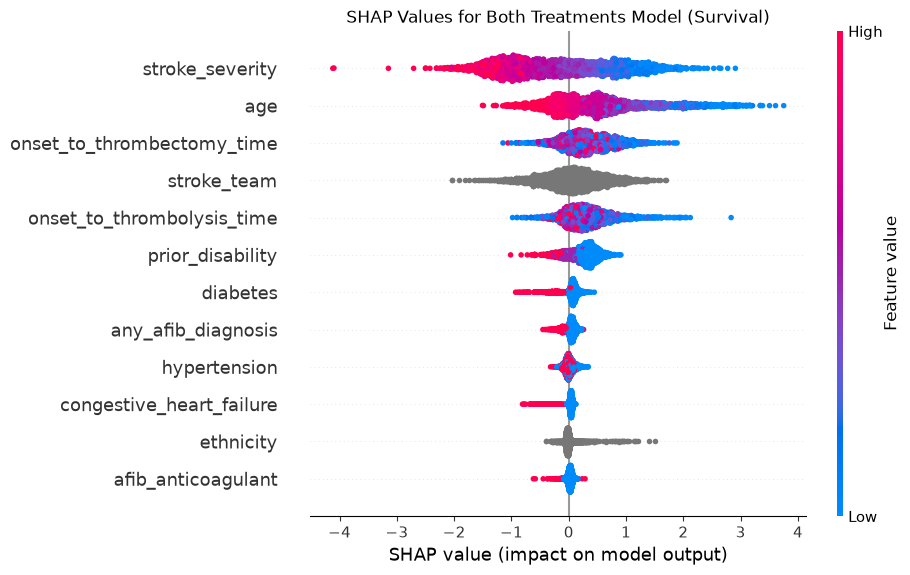

In [22]:
# Get data for patients who thrombectomy and thrombolysis
both_treatments = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombectomy_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombolysis_time"] < 99999)
].copy()

# Fit regression model for predicted benefit vs thrombectomy time
reg_X = both_treatments[["onset_to_thrombectomy_time"]]
reg_y = both_treatments["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombectomy_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombectomy_time", "onset_to_thrombectomy_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombectomy_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombectomy_time",
    y="log_odds_diff_treated_no_treatment",
    data=both_treatments,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(
    f"Effect of Thrombectomy Time on Predicted Benefit (Survival)\n"
    "(Thrombectomy and thrombolysis)"
)
plt.xlabel('Onset to Thrombectomy Time (mins)')
plt.ylabel(f'Predicted Benefit\n(Log Odds improvement in Survival vs no treatment)')
plt.savefig(f'./output/thrombectomy_and_thrombolysis_thrombectomy_time_effect_mrs_{
    mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()

# Use patients who received both thrombolysis and thrombectomy
both_treatments_X = both_treatments[X_fields]
explainer = shap.Explainer(models[0])
shap_values = explainer(both_treatments_X)

# Plot beeswarm plot for SHAP values
shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.title(f"SHAP Values for Both Treatments Model (Survival)")
plt.savefig(
    f"./output/shap_beeswarm_both_treatments_mrs_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Analysis of thrombectomy and thrombolysis (analyse time to thrombolysis)

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.097
Model:                                            OLS   Adj. R-squared:                  0.097
Method:                                 Least Squares   F-statistic:                     312.7
Date:                                Tue, 14 Jul 2026   Prob (F-statistic):           1.58e-66
Time:                                        12:13:00   Log-Likelihood:                -4516.2
No. Observations:                                2898   AIC:                             9036.
Df Residuals:                                    2896   BIC:                             9048.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

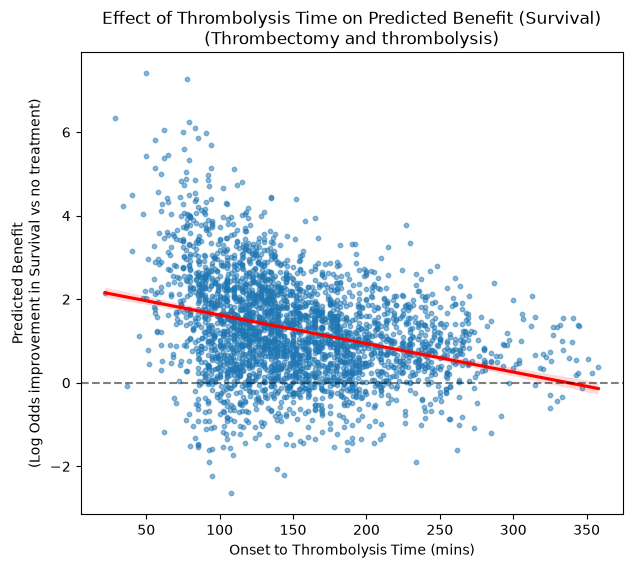

In [23]:
# Fit regression model for predicted benefit vs thrombolysis time
reg_X = both_treatments[["onset_to_thrombolysis_time"]]
reg_y = both_treatments["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombolysis_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombolysis_time", "onset_to_thrombolysis_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombolysis_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombolysis_time",
    y="log_odds_diff_treated_no_treatment",
    data=both_treatments,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(
    f"Effect of Thrombolysis Time on Predicted Benefit (Survival)\n"
    "(Thrombectomy and thrombolysis)"
)
plt.xlabel('Onset to Thrombolysis Time (mins)')
plt.ylabel(f'Predicted Benefit\n(Log Odds improvement in Survival vs no treatment)')
plt.savefig(f'./output/thrombectomy_and_thrombolysis_thrombolysis_time_effect_mrs_{
    mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()


SHAP plot is the same as above.